In [1]:
# ============================================================
# LAB 05 - HOG BASED INDUSTRIAL DEFECT DETECTION
# CELL 1: INSTALL LIBRARIES
# ============================================================

!pip -q install kagglehub scikit-image seaborn opencv-python-headless

In [2]:
# ============================================================
# CELL 2: IMPORT LIBRARIES
# ============================================================

import os
import re
import cv2
import glob
import json
import math
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from collections import Counter
from xml.etree import ElementTree as ET

from skimage.feature import hog
from skimage import exposure

from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("All libraries imported successfully.")

All libraries imported successfully.


In [3]:
# ============================================================
# CELL 3: DOWNLOAD DATASET DIRECTLY FROM KAGGLE
# ============================================================

import kagglehub

DATASET_HANDLE = "sovitrath/neu-steel-surface-defect-detect-trainvalid-split"

print("Downloading/accessing Kaggle dataset...")
dataset_path = kagglehub.dataset_download(DATASET_HANDLE)

print("\nDataset successfully accessed.")
print("Dataset path:")
print(dataset_path)

Downloading/accessing Kaggle dataset...
Using Colab cache for faster access to the 'neu-steel-surface-defect-detect-trainvalid-split' dataset.

Dataset successfully accessed.
Dataset path:
/kaggle/input/neu-steel-surface-defect-detect-trainvalid-split


In [4]:
# ============================================================
# CELL 4: INSPECT DATASET STRUCTURE
# ============================================================

dataset_root = Path(dataset_path)

print("Dataset root:")
print(dataset_root)

print("\nTop-level contents:")
for item in sorted(dataset_root.iterdir()):
    print(" -", item.name)

Dataset root:
/kaggle/input/neu-steel-surface-defect-detect-trainvalid-split

Top-level contents:
 - train_annotations
 - train_images
 - valid_annotations
 - valid_images


In [5]:
# ============================================================
# CELL 5: FIND DATASET FOLDERS AUTOMATICALLY
# ============================================================

def find_directory(root, possible_names):
    """
    Recursively searches for a directory whose name matches
    one of the possible names.
    """
    possible_names = {name.lower() for name in possible_names}

    for path in root.rglob("*"):
        if path.is_dir() and path.name.lower() in possible_names:
            return path

    return None


train_images_dir = find_directory(
    dataset_root,
    ["train_images", "train", "training_images"]
)

valid_images_dir = find_directory(
    dataset_root,
    ["valid_images", "val_images", "validation_images", "valid", "validation"]
)

train_annotations_dir = find_directory(
    dataset_root,
    ["train_annotations", "train_annotation", "annotations_train"]
)

valid_annotations_dir = find_directory(
    dataset_root,
    ["valid_annotations", "valid_annotation", "val_annotations",
     "validation_annotations"]
)

print("TRAIN IMAGES       :", train_images_dir)
print("VALIDATION IMAGES  :", valid_images_dir)
print("TRAIN ANNOTATIONS  :", train_annotations_dir)
print("VALID ANNOTATIONS  :", valid_annotations_dir)

TRAIN IMAGES       : /kaggle/input/neu-steel-surface-defect-detect-trainvalid-split/train_images
VALIDATION IMAGES  : /kaggle/input/neu-steel-surface-defect-detect-trainvalid-split/valid_images
TRAIN ANNOTATIONS  : /kaggle/input/neu-steel-surface-defect-detect-trainvalid-split/train_annotations
VALID ANNOTATIONS  : /kaggle/input/neu-steel-surface-defect-detect-trainvalid-split/valid_annotations


In [6]:
# ============================================================
# CELL 6: CHECK DATASET FILES
# ============================================================

def get_image_files(folder):
    if folder is None:
        return []

    extensions = ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.JPG", "*.JPEG", "*.PNG"]
    files = []

    for ext in extensions:
        files.extend(folder.glob(ext))

    return sorted(files)


train_image_files = get_image_files(train_images_dir)
valid_image_files = get_image_files(valid_images_dir)

print("Training images  :", len(train_image_files))
print("Validation images:", len(valid_image_files))

if train_image_files:
    print("\nExample training images:")
    for f in train_image_files[:5]:
        print(f.name)

if valid_image_files:
    print("\nExample validation images:")
    for f in valid_image_files[:5]:
        print(f.name)

Training images  : 1700
Validation images: 100

Example training images:
crazing_10.jpg
crazing_100.jpg
crazing_101.jpg
crazing_102.jpg
crazing_103.jpg

Example validation images:
crazing_1.jpg
crazing_109.jpg
crazing_127.jpg
crazing_145.jpg
crazing_163.jpg


In [7]:
# ============================================================
# CELL 7: LABEL EXTRACTION
# ============================================================

EXPECTED_CLASSES = [
    "crazing",
    "inclusion",
    "patches",
    "pitted_surface",
    "rolled_in_scale",
    "scratches"
]

CLASS_NORMALIZATION = {
    "crazing": "crazing",
    "inclusion": "inclusion",
    "patches": "patches",
    "patch": "patches",
    "pitted_surface": "pitted_surface",
    "pitted": "pitted_surface",
    "rolled_in_scale": "rolled_in_scale",
    "rolled-in_scale": "rolled_in_scale",
    "rolled in scale": "rolled_in_scale",
    "scratches": "scratches",
    "scratch": "scratches"
}


def normalize_class_name(name):
    if name is None:
        return None

    name = str(name).strip().lower()
    name = name.replace("-", "_")

    if name in CLASS_NORMALIZATION:
        return CLASS_NORMALIZATION[name]

    name2 = re.sub(r"[^a-z0-9_ ]", "", name)
    name2 = re.sub(r"\s+", "_", name2)

    if name2 in CLASS_NORMALIZATION:
        return CLASS_NORMALIZATION[name2]

    for key, value in CLASS_NORMALIZATION.items():
        if key.replace("-", "_").replace(" ", "_") in name2:
            return value

    return None


def label_from_xml(xml_file):
    """
    Extract the object/class name from an XML annotation.
    """
    try:
        tree = ET.parse(xml_file)
        root = tree.getroot()

        # Look for <name>
        for elem in root.iter():
            if elem.tag.lower() == "name":
                label = normalize_class_name(elem.text)
                if label is not None:
                    return label

    except Exception:
        pass

    return None


def label_from_filename(filename):
    """
    Fallback label extraction from filename.
    """
    name = filename.lower()

    for class_name in EXPECTED_CLASSES:
        if class_name in name:
            return class_name

        if class_name.replace("_", "-") in name:
            return class_name

        if class_name.replace("_", " ") in name:
            return class_name

    # Common abbreviations
    abbreviation_map = {
        "_cr_": "crazing",
        "_in_": "inclusion",
        "_pa_": "patches",
        "_ps_": "pitted_surface",
        "_rs_": "rolled_in_scale",
        "_sc_": "scratches"
    }

    for pattern, label in abbreviation_map.items():
        if pattern in name:
            return label

    return None


def find_xml_for_image(image_path, annotation_dir):
    if annotation_dir is None:
        return None

    stem = image_path.stem

    candidates = [
        annotation_dir / f"{stem}.xml",
        annotation_dir / f"{stem}.XML"
    ]

    for candidate in candidates:
        if candidate.exists():
            return candidate

    # Recursive fallback
    matches = list(annotation_dir.rglob(f"{stem}.xml"))
    if matches:
        return matches[0]

    matches = list(annotation_dir.rglob(f"{stem}.XML"))
    if matches:
        return matches[0]

    return None


def get_label(image_path, annotation_dir):
    # First try XML
    xml_file = find_xml_for_image(image_path, annotation_dir)

    if xml_file is not None:
        label = label_from_xml(xml_file)
        if label is not None:
            return label

    # Fallback to filename
    return label_from_filename(image_path.name)


print("Label extraction functions created successfully.")

Label extraction functions created successfully.


In [8]:
# ============================================================
# CELL 8: CREATE DATAFRAME
# ============================================================

def build_dataframe(image_files, annotation_dir, split_name):
    records = []

    for image_path in image_files:
        label = get_label(image_path, annotation_dir)

        if label is not None:
            records.append({
                "filepath": str(image_path),
                "filename": image_path.name,
                "label": label,
                "split": split_name
            })

    return pd.DataFrame(records)


train_df = build_dataframe(
    train_image_files,
    train_annotations_dir,
    "train"
)

valid_df = build_dataframe(
    valid_image_files,
    valid_annotations_dir,
    "validation"
)

print("Training records  :", len(train_df))
print("Validation records:", len(valid_df))

print("\nTraining class distribution:")
print(train_df["label"].value_counts().sort_index())

print("\nValidation class distribution:")
print(valid_df["label"].value_counts().sort_index())

Training records  : 1700
Validation records: 100

Training class distribution:
label
crazing            283
inclusion          283
patches            284
pitted_surface     283
rolled_in_scale    283
scratches          284
Name: count, dtype: int64

Validation class distribution:
label
crazing            17
inclusion          17
patches            16
pitted_surface     17
rolled_in_scale    17
scratches          16
Name: count, dtype: int64


In [9]:
# ============================================================
# CELL 9: DATASET VALIDATION
# ============================================================

if len(train_df) == 0:
    raise RuntimeError(
        "No training images with labels were found. "
        "Please inspect the dataset folder structure printed above."
    )

if len(valid_df) == 0:
    raise RuntimeError(
        "No validation images with labels were found. "
        "Please inspect the dataset folder structure printed above."
    )

print("Dataset validation passed.")

print("\nClasses found:")
classes_found = sorted(
    set(train_df["label"].unique()) | set(valid_df["label"].unique())
)

for i, cls in enumerate(classes_found):
    print(f"{i}: {cls}")

Dataset validation passed.

Classes found:
0: crazing
1: inclusion
2: patches
3: pitted_surface
4: rolled_in_scale
5: scratches


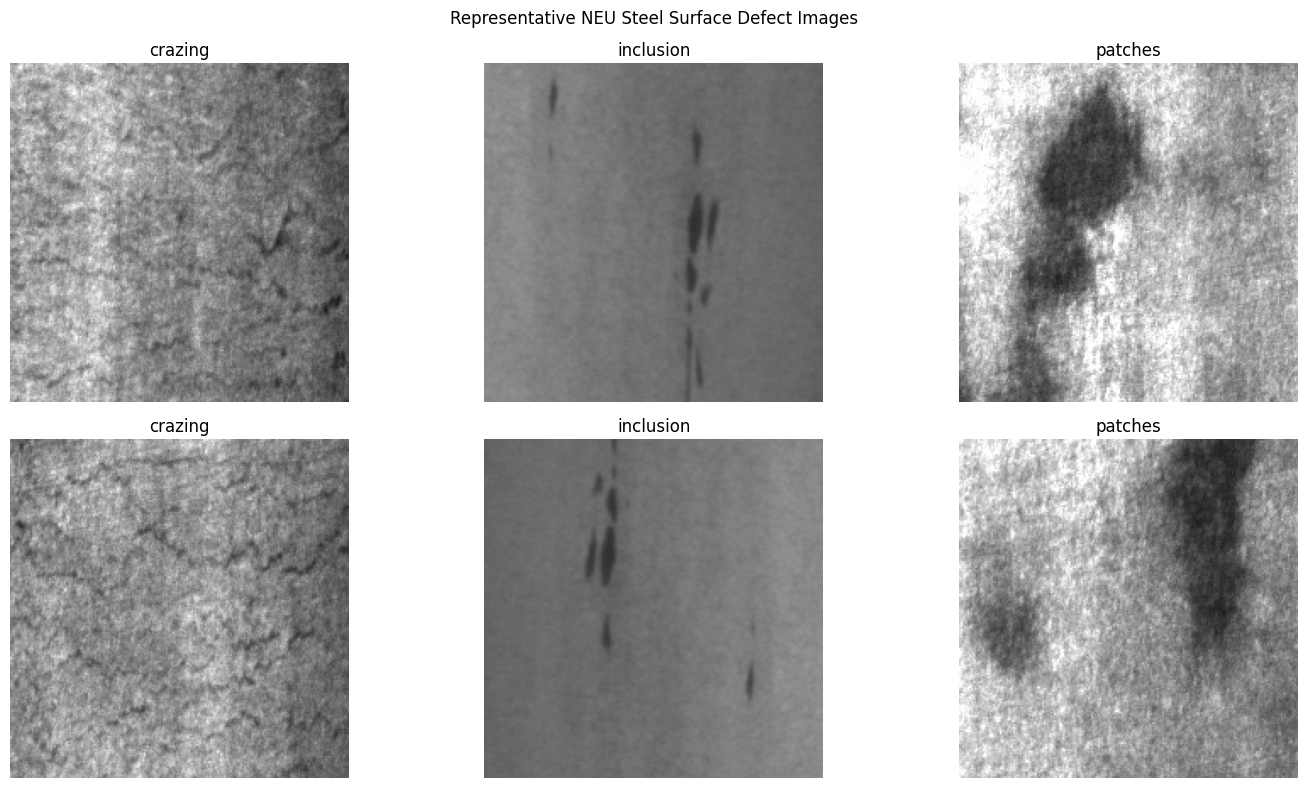

In [10]:
# ============================================================
# CELL 10: VISUALIZE REPRESENTATIVE DATASET IMAGES
# ============================================================

fig, axes = plt.subplots(
    2,
    min(3, len(classes_found)),
    figsize=(15, 8)
)

axes = np.array(axes).reshape(2, -1)

for col, class_name in enumerate(classes_found[:3]):

    sample_rows = train_df[train_df["label"] == class_name]

    if len(sample_rows) == 0:
        continue

    for row in range(2):
        image_path = sample_rows.iloc[
            min(row, len(sample_rows)-1)
        ]["filepath"]

        image = cv2.imread(image_path)

        if image is None:
            continue

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        axes[row, col].imshow(image)
        axes[row, col].set_title(class_name)
        axes[row, col].axis("off")

plt.suptitle("Representative NEU Steel Surface Defect Images")
plt.tight_layout()
plt.show()

Processed image shape: (128, 128)
Minimum: 0.13333334
Maximum: 0.972549


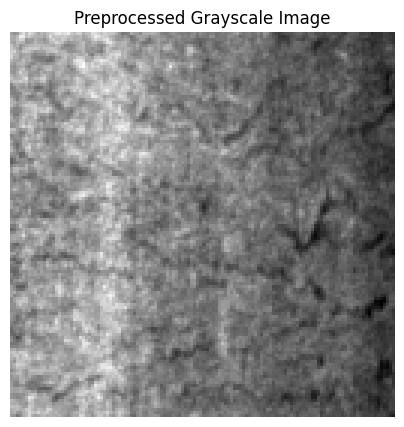

In [11]:
# ============================================================
# CELL 11: IMAGE PREPROCESSING
# ============================================================

IMAGE_SIZE = (128, 128)


def load_and_preprocess_image(image_path, image_size=IMAGE_SIZE):
    """
    Load image, resize it, convert to grayscale,
    and normalize pixel values.
    """

    image = cv2.imread(str(image_path))

    if image is None:
        raise ValueError(f"Could not read image: {image_path}")

    # Resize
    image = cv2.resize(
        image,
        image_size,
        interpolation=cv2.INTER_AREA
    )

    # Convert to grayscale
    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )

    # Normalize
    gray = gray.astype(np.float32) / 255.0

    return gray


# Test preprocessing
sample_path = train_df.iloc[0]["filepath"]

processed_image = load_and_preprocess_image(sample_path)

print("Processed image shape:", processed_image.shape)
print("Minimum:", processed_image.min())
print("Maximum:", processed_image.max())

plt.figure(figsize=(5, 5))
plt.imshow(processed_image, cmap="gray")
plt.title("Preprocessed Grayscale Image")
plt.axis("off")
plt.show()

In [12]:
# ============================================================
# CELL 12: HOG FEATURE EXTRACTION
# ============================================================

def extract_hog_features(
    image,
    pixels_per_cell=(8, 8),
    orientations=9,
    cells_per_block=(2, 2)
):
    """
    Extract HOG feature vector from a grayscale image.
    """

    features = hog(
        image,
        orientations=orientations,
        pixels_per_cell=pixels_per_cell,
        cells_per_block=cells_per_block,
        block_norm="L2-Hys",
        feature_vector=True
    )

    return features.astype(np.float32)


# Test HOG
sample_hog = extract_hog_features(
    processed_image,
    pixels_per_cell=(8, 8),
    orientations=9
)

print("HOG feature vector length:", len(sample_hog))

HOG feature vector length: 8100


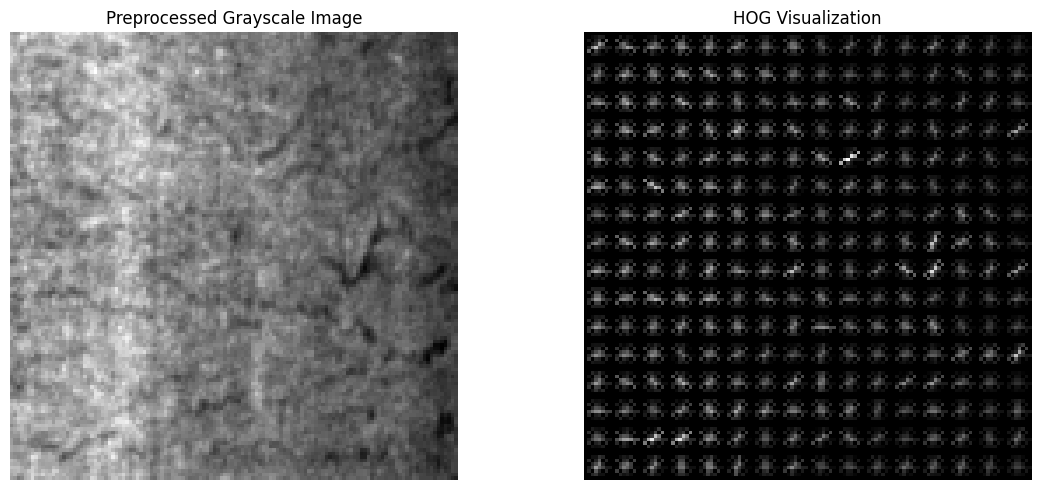

HOG feature length: 8100


In [13]:
# ============================================================
# CELL 13: VISUALIZE HOG REPRESENTATION
# ============================================================

sample_path = train_df.iloc[0]["filepath"]

gray_image = load_and_preprocess_image(sample_path)

features, hog_image = hog(
    gray_image,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    block_norm="L2-Hys",
    visualize=True,
    feature_vector=True
)

hog_image_rescaled = exposure.rescale_intensity(
    hog_image,
    in_range=(0, np.max(hog_image) if np.max(hog_image) > 0 else 1)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(gray_image, cmap="gray")
axes[0].set_title("Preprocessed Grayscale Image")
axes[0].axis("off")

axes[1].imshow(hog_image_rescaled, cmap="gray")
axes[1].set_title("HOG Visualization")
axes[1].axis("off")

plt.tight_layout()
plt.show()

print("HOG feature length:", len(features))

In [14]:
# ============================================================
# CELL 14: PREPARE HOG DATASET
# ============================================================

def create_hog_dataset(
    dataframe,
    pixels_per_cell=(8, 8),
    orientations=9
):
    """
    Load all images and create HOG feature matrix.
    """

    feature_list = []
    labels = []

    total = len(dataframe)

    for idx, row in enumerate(dataframe.itertuples(index=False)):

        image = load_and_preprocess_image(row.filepath)

        feature_vector = extract_hog_features(
            image,
            pixels_per_cell=pixels_per_cell,
            orientations=orientations
        )

        feature_list.append(feature_vector)
        labels.append(row.label)

        if (idx + 1) % 250 == 0 or idx == total - 1:
            print(
                f"Processed {idx + 1}/{total} images",
                end="\r"
            )

    print()

    return np.asarray(feature_list, dtype=np.float32), np.asarray(labels)


print("Dataset preparation function ready.")

Dataset preparation function ready.


In [15]:
# ============================================================
# CELL 15: ENCODE LABELS
# ============================================================

label_encoder = LabelEncoder()

all_labels = pd.concat([
    train_df["label"],
    valid_df["label"]
]).unique()

label_encoder.fit(all_labels)

class_names = list(label_encoder.classes_)

print("Encoded classes:")

for i, name in enumerate(class_names):
    print(i, "=", name)

Encoded classes:
0 = crazing
1 = inclusion
2 = patches
3 = pitted_surface
4 = rolled_in_scale
5 = scratches


In [17]:
# ============================================================
# TASK 16 - FAST HOG PARAMETER EXPERIMENT
# ============================================================

import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

from skimage.feature import hog
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score
from joblib import Parallel, delayed

SEED = 42
np.random.seed(SEED)

# Fast balanced tuning dataset
TUNE_TRAIN_PER_CLASS = 30
TUNE_VALID_PER_CLASS = 15

print("Creating small balanced tuning dataset...")

def balanced_sample(df, n_per_class):
    parts = []

    for label in sorted(df["label"].unique()):
        temp = df[df["label"] == label]

        n = min(n_per_class, len(temp))

        parts.append(
            temp.sample(
                n=n,
                random_state=SEED
            )
        )

    return pd.concat(parts).sample(
        frac=1,
        random_state=SEED
    ).reset_index(drop=True)


tune_train_df = balanced_sample(
    train_df,
    TUNE_TRAIN_PER_CLASS
)

tune_valid_df = balanced_sample(
    valid_df,
    TUNE_VALID_PER_CLASS
)

print("Tuning training images:", len(tune_train_df))
print("Tuning validation images:", len(tune_valid_df))


# ------------------------------------------------------------
# Load images ONCE instead of loading them repeatedly
# ------------------------------------------------------------

def load_gray_fast(path, size=(128, 128)):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        return None

    img = cv2.resize(img, size)
    img = img.astype(np.float32) / 255.0

    return img


def load_dataset_to_memory(df):
    images = []
    labels = []

    for _, row in df.iterrows():

        img = load_gray_fast(row["filepath"])

        if img is not None:
            images.append(img)
            labels.append(row["label"])

    return images, np.array(labels)


print("\nLoading tuning images into memory...")

tune_train_images, tune_train_labels = load_dataset_to_memory(
    tune_train_df
)

tune_valid_images, tune_valid_labels = load_dataset_to_memory(
    tune_valid_df
)

print("Images loaded successfully.")


# ------------------------------------------------------------
# FAST HOG extraction
# ------------------------------------------------------------

def hog_from_image(img, orientations, cell_size):

    pixels_per_cell = (cell_size, cell_size)

    feature = hog(
        img,
        orientations=orientations,
        pixels_per_cell=pixels_per_cell,
        cells_per_block=(2, 2),
        block_norm="L2-Hys"
    )

    return feature.astype(np.float32)


def extract_hog_memory(images, orientations, cell_size):

    features = Parallel(
        n_jobs=-1,
        prefer="threads"
    )(
        delayed(hog_from_image)(
            img,
            orientations,
            cell_size
        )
        for img in images
    )

    return np.asarray(features, dtype=np.float32)


# ------------------------------------------------------------
# Required HOG experiments
# ------------------------------------------------------------

cell_sizes = [4, 8, 16]
orientations_list = [6, 9, 12]

experiment_results = []

print("\nStarting FAST HOG experiments...\n")

for cell_size in cell_sizes:

    for orientations in orientations_list:

        print(
            f"Testing Cell={cell_size}x{cell_size}, "
            f"Orientations={orientations}"
        )

        X_train = extract_hog_memory(
            tune_train_images,
            orientations,
            cell_size
        )

        X_valid = extract_hog_memory(
            tune_valid_images,
            orientations,
            cell_size
        )

        # Fast SVM
        svm = LinearSVC(
            C=1.0,
            random_state=SEED,
            max_iter=3000
        )

        svm.fit(
            X_train,
            tune_train_labels
        )

        predictions = svm.predict(X_valid)

        accuracy = accuracy_score(
            tune_valid_labels,
            predictions
        )

        f1 = f1_score(
            tune_valid_labels,
            predictions,
            average="weighted"
        )

        experiment_results.append({
            "Cell Size": f"{cell_size}x{cell_size}",
            "Orientations": orientations,
            "Accuracy": accuracy,
            "F1 Score": f1,
            "Features": X_train.shape[1]
        })

        print(
            f"Accuracy: {accuracy:.4f} | "
            f"F1: {f1:.4f} | "
            f"Features: {X_train.shape[1]}"
        )

        del X_train
        del X_valid
        del svm

print("\nAll HOG experiments completed.")

Creating small balanced tuning dataset...
Tuning training images: 180
Tuning validation images: 90

Loading tuning images into memory...
Images loaded successfully.

Starting FAST HOG experiments...

Testing Cell=4x4, Orientations=6
Accuracy: 0.6000 | F1: 0.5836 | Features: 23064
Testing Cell=4x4, Orientations=9
Accuracy: 0.6333 | F1: 0.6212 | Features: 34596
Testing Cell=4x4, Orientations=12
Accuracy: 0.5889 | F1: 0.5550 | Features: 46128
Testing Cell=8x8, Orientations=6
Accuracy: 0.6111 | F1: 0.5626 | Features: 5400
Testing Cell=8x8, Orientations=9
Accuracy: 0.5778 | F1: 0.5505 | Features: 8100
Testing Cell=8x8, Orientations=12
Accuracy: 0.5556 | F1: 0.5282 | Features: 10800
Testing Cell=16x16, Orientations=6
Accuracy: 0.5667 | F1: 0.5566 | Features: 1176
Testing Cell=16x16, Orientations=9
Accuracy: 0.6111 | F1: 0.5991 | Features: 1764
Testing Cell=16x16, Orientations=12
Accuracy: 0.7222 | F1: 0.7167 | Features: 2352

All HOG experiments completed.


In [18]:
# ============================================================
# TASK 17 - HOG EXPERIMENT RESULTS
# ============================================================

hog_results = pd.DataFrame(experiment_results)

hog_results = hog_results.sort_values(
    by=["F1 Score", "Accuracy"],
    ascending=False
).reset_index(drop=True)

print("\nHOG PARAMETER RESULTS")
print("=" * 70)

display(hog_results)

best_cell_text = hog_results.iloc[0]["Cell Size"]
best_orientations = int(
    hog_results.iloc[0]["Orientations"]
)

best_cell_size = int(
    best_cell_text.split("x")[0]
)

print("\nBEST HOG CONFIGURATION")
print("-" * 40)
print("Cell Size:", best_cell_text)
print("Orientations:", best_orientations)
print("Accuracy:", round(hog_results.iloc[0]["Accuracy"], 4))
print("F1 Score:", round(hog_results.iloc[0]["F1 Score"], 4))


HOG PARAMETER RESULTS


,Cell Size,Orientations,Accuracy,F1 Score,Features
0,16x16,12,0.722222,0.716666,2352
1,4x4,9,0.633333,0.621206,34596
2,16x16,9,0.611111,0.599066,1764
3,4x4,6,0.600000,0.583641,23064
4,8x8,6,0.611111,0.562573,5400
5,16x16,6,0.566667,0.556591,1176
6,4x4,12,0.588889,0.554995,46128
7,8x8,9,0.577778,0.550492,8100
8,8x8,12,0.555556,0.528189,10800



BEST HOG CONFIGURATION
----------------------------------------
Cell Size: 16x16
Orientations: 12
Accuracy: 0.7222
F1 Score: 0.7167


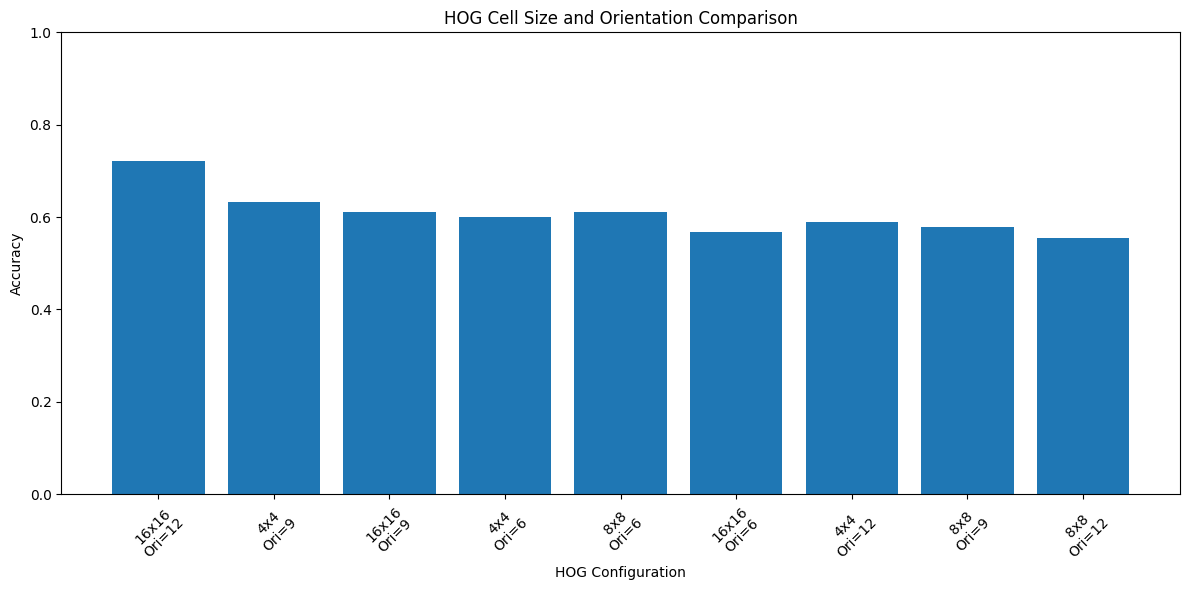

In [19]:
# ============================================================
# TASK 18 - HOG COMPARISON GRAPH
# ============================================================

plt.figure(figsize=(12, 6))

labels = (
    hog_results["Cell Size"]
    + "\nOri=" +
    hog_results["Orientations"].astype(str)
)

plt.bar(
    labels,
    hog_results["Accuracy"]
)

plt.xlabel("HOG Configuration")
plt.ylabel("Accuracy")
plt.title("HOG Cell Size and Orientation Comparison")
plt.ylim(0, 1)

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "/content/hog_parameter_comparison.png",
    dpi=150
)

plt.show()

In [20]:
# ============================================================
# TASK 19 - FINAL HOG DATASET
# ============================================================

# Increase these numbers if your Colab is fast.
# This gives a good balance between speed and performance.

FINAL_TRAIN_PER_CLASS = 200
FINAL_VALID_PER_CLASS = 100

print("Creating final balanced dataset...")

final_train_df = balanced_sample(
    train_df,
    FINAL_TRAIN_PER_CLASS
)

final_valid_df = balanced_sample(
    valid_df,
    FINAL_VALID_PER_CLASS
)

print("Final training images:", len(final_train_df))
print("Final validation images:", len(final_valid_df))


print("\nLoading final images...")

final_train_images, final_train_labels = load_dataset_to_memory(
    final_train_df
)

final_valid_images, final_valid_labels = load_dataset_to_memory(
    final_valid_df
)

print("Final images loaded.")

Creating final balanced dataset...
Final training images: 1200
Final validation images: 100

Loading final images...
Final images loaded.


In [21]:
# ============================================================
# TASK 20 - FINAL HOG FEATURE EXTRACTION
# ============================================================

print(
    f"Using best configuration: "
    f"{best_cell_size}x{best_cell_size}, "
    f"{best_orientations} orientations"
)

print("\nExtracting training HOG features...")

X_train_final = extract_hog_memory(
    final_train_images,
    best_orientations,
    best_cell_size
)

print(
    "Training HOG shape:",
    X_train_final.shape
)

print("\nExtracting validation HOG features...")

X_valid_final = extract_hog_memory(
    final_valid_images,
    best_orientations,
    best_cell_size
)

print(
    "Validation HOG shape:",
    X_valid_final.shape
)

print("\nHOG extraction completed.")

Using best configuration: 16x16, 12 orientations

Extracting training HOG features...
Training HOG shape: (1200, 2352)

Extracting validation HOG features...
Validation HOG shape: (100, 2352)

HOG extraction completed.


In [22]:
# ============================================================
# TASK 21 - HOG + SVM
# ============================================================

svm_model = LinearSVC(
    C=1.0,
    random_state=SEED,
    max_iter=5000
)

print("Training SVM...")

svm_model.fit(
    X_train_final,
    final_train_labels
)

svm_predictions = svm_model.predict(
    X_valid_final
)

svm_accuracy = accuracy_score(
    final_valid_labels,
    svm_predictions
)

svm_f1 = f1_score(
    final_valid_labels,
    svm_predictions,
    average="weighted"
)

print("\nSVM RESULTS")
print("=" * 40)
print("Accuracy:", round(svm_accuracy, 4))
print("F1 Score:", round(svm_f1, 4))

Training SVM...

SVM RESULTS
Accuracy: 0.74
F1 Score: 0.7343


In [23]:
# ============================================================
# TASK 22 - HOG + RANDOM FOREST
# ============================================================

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=SEED,
    n_jobs=-1
)

print("Training Random Forest...")

rf_model.fit(
    X_train_final,
    final_train_labels
)

rf_predictions = rf_model.predict(
    X_valid_final
)

rf_accuracy = accuracy_score(
    final_valid_labels,
    rf_predictions
)

rf_f1 = f1_score(
    final_valid_labels,
    rf_predictions,
    average="weighted"
)

print("\nRANDOM FOREST RESULTS")
print("=" * 40)
print("Accuracy:", round(rf_accuracy, 4))
print("F1 Score:", round(rf_f1, 4))

Training Random Forest...

RANDOM FOREST RESULTS
Accuracy: 0.88
F1 Score: 0.8786


CLASSIFIER COMPARISON


,Classifier,Accuracy,F1 Score
0,HOG + SVM,0.74,0.734283
1,HOG + Random Forest,0.88,0.878586


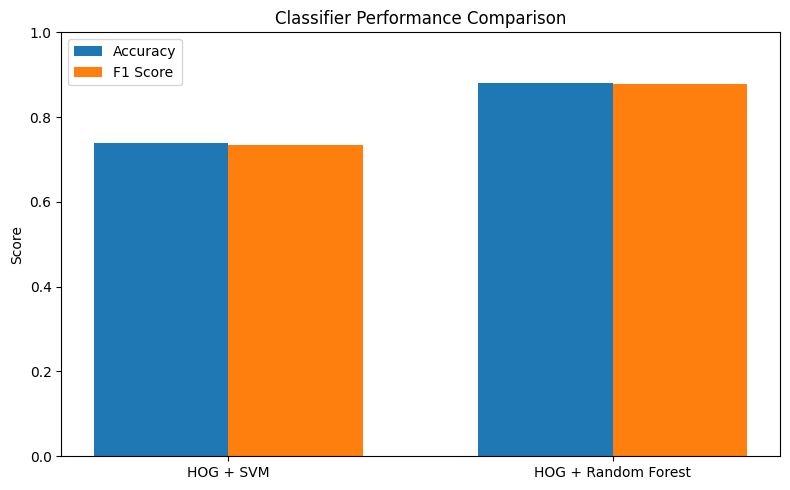

In [24]:
# ============================================================
# TASK 23 - CLASSIFIER COMPARISON
# ============================================================

classifier_results = pd.DataFrame({
    "Classifier": [
        "HOG + SVM",
        "HOG + Random Forest"
    ],
    "Accuracy": [
        svm_accuracy,
        rf_accuracy
    ],
    "F1 Score": [
        svm_f1,
        rf_f1
    ]
})

print("CLASSIFIER COMPARISON")
print("=" * 60)

display(classifier_results)

plt.figure(figsize=(8, 5))

x = np.arange(len(classifier_results))
width = 0.35

plt.bar(
    x - width/2,
    classifier_results["Accuracy"],
    width,
    label="Accuracy"
)

plt.bar(
    x + width/2,
    classifier_results["F1 Score"],
    width,
    label="F1 Score"
)

plt.xticks(
    x,
    classifier_results["Classifier"]
)

plt.ylabel("Score")
plt.title("Classifier Performance Comparison")
plt.ylim(0, 1)
plt.legend()

plt.tight_layout()

plt.savefig(
    "/content/classifier_comparison.png",
    dpi=150
)

plt.show()

In [25]:
# ============================================================
# TASK 24 - CLASSIFICATION REPORT
# ============================================================

from sklearn.metrics import classification_report

print("=" * 70)
print("SVM CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        final_valid_labels,
        svm_predictions
    )
)

print("\n")
print("=" * 70)
print("RANDOM FOREST CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        final_valid_labels,
        rf_predictions
    )
)

SVM CLASSIFICATION REPORT
                 precision    recall  f1-score   support

        crazing       0.77      0.59      0.67        17
      inclusion       0.67      0.94      0.78        17
        patches       0.57      0.75      0.65        16
 pitted_surface       0.58      0.41      0.48        17
rolled_in_scale       1.00      1.00      1.00        17
      scratches       0.92      0.75      0.83        16

       accuracy                           0.74       100
      macro avg       0.75      0.74      0.73       100
   weighted avg       0.75      0.74      0.73       100



RANDOM FOREST CLASSIFICATION REPORT
                 precision    recall  f1-score   support

        crazing       0.89      1.00      0.94        17
      inclusion       0.73      0.94      0.82        17
        patches       0.92      0.75      0.83        16
 pitted_surface       0.86      0.71      0.77        17
rolled_in_scale       1.00      1.00      1.00        17
      scratches     

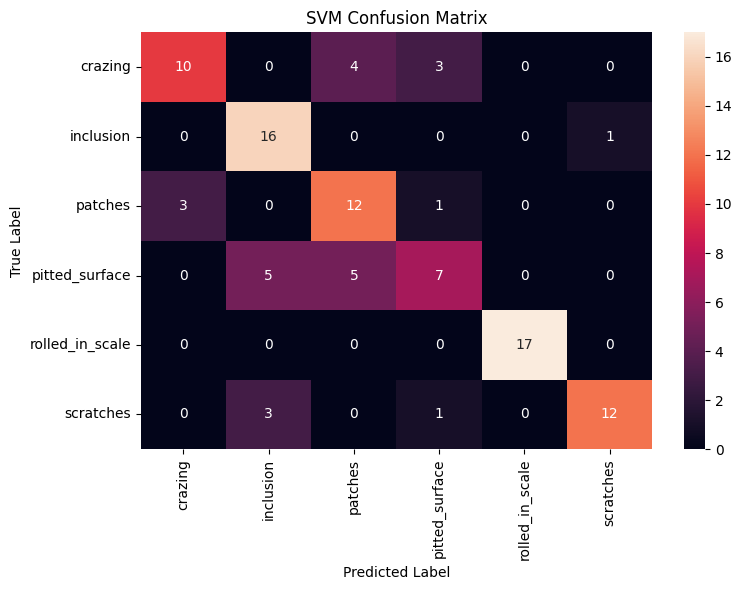

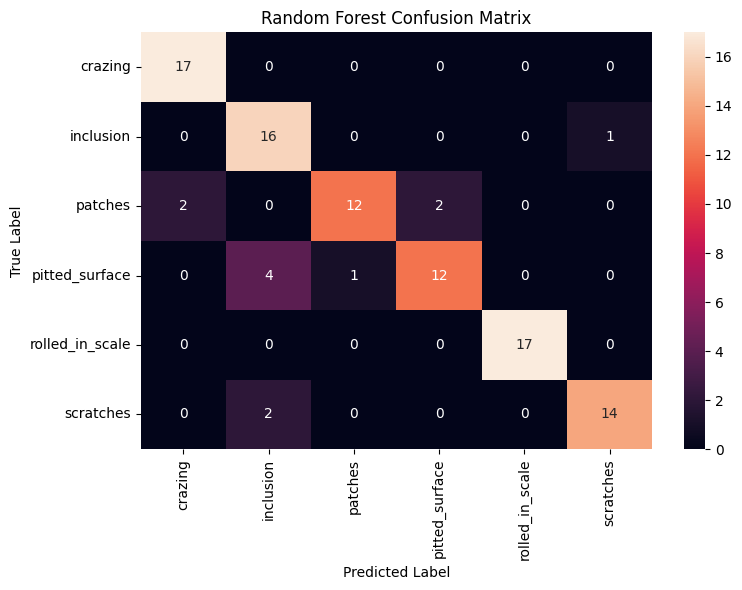

In [26]:
# ============================================================
# TASK 25 - CONFUSION MATRICES
# ============================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns

class_names = sorted(
    np.unique(final_valid_labels)
)

# ---------------- SVM ----------------

cm_svm = confusion_matrix(
    final_valid_labels,
    svm_predictions,
    labels=class_names
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("SVM Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "/content/svm_confusion_matrix.png",
    dpi=150
)

plt.show()


# ---------------- Random Forest ----------------

cm_rf = confusion_matrix(
    final_valid_labels,
    rf_predictions,
    labels=class_names
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Random Forest Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "/content/rf_confusion_matrix.png",
    dpi=150
)

plt.show()

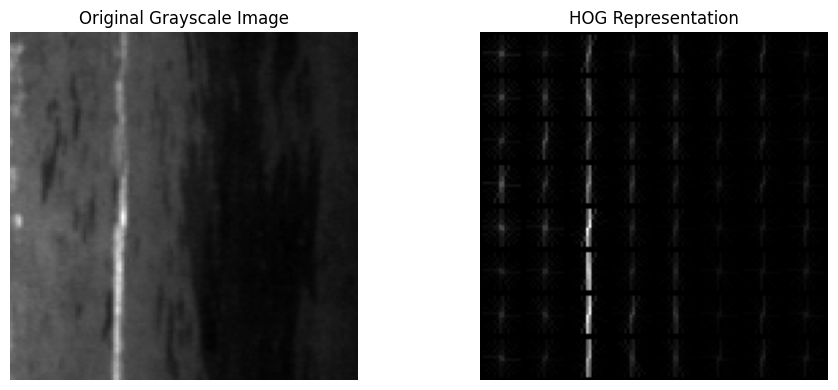

In [27]:
# ============================================================
# TASK 26 - HOG VISUALIZATION
# ============================================================

from skimage.feature import hog

sample_image = final_train_images[0]

hog_features, hog_image = hog(
    sample_image,
    orientations=best_orientations,
    pixels_per_cell=(
        best_cell_size,
        best_cell_size
    ),
    cells_per_block=(2, 2),
    block_norm="L2-Hys",
    visualize=True
)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(sample_image, cmap="gray")
plt.title("Original Grayscale Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(hog_image, cmap="gray")
plt.title("HOG Representation")
plt.axis("off")

plt.tight_layout()

plt.savefig(
    "/content/hog_visualization.png",
    dpi=150
)

plt.show()

In [28]:
# ============================================================
# TASK 27 - ROBUSTNESS TESTING
# ============================================================

def brightness_change(img):
    result = img * 1.4
    return np.clip(result, 0, 1)


def gaussian_noise(img):
    noise = np.random.normal(
        0,
        0.08,
        img.shape
    )

    result = img + noise

    return np.clip(result, 0, 1)


def rotation_change(img):
    h, w = img.shape

    matrix = cv2.getRotationMatrix2D(
        (w // 2, h // 2),
        15,
        1.0
    )

    rotated = cv2.warpAffine(
        img,
        matrix,
        (w, h)
    )

    return rotated


def blur_change(img):
    blurred = cv2.GaussianBlur(
        img,
        (7, 7),
        0
    )

    return blurred


robustness_functions = {
    "Brightness Variation": brightness_change,
    "Gaussian Noise": gaussian_noise,
    "Rotation": rotation_change,
    "Blur": blur_change
}


# Use limited images to keep robustness testing FAST
ROBUSTNESS_SAMPLES = min(
    200,
    len(final_valid_images)
)

robust_images = final_valid_images[
    :ROBUSTNESS_SAMPLES
]

robust_labels = final_valid_labels[
    :ROBUSTNESS_SAMPLES
]


robustness_results = []

for condition, transform in robustness_functions.items():

    print("Testing:", condition)

    transformed_images = [
        transform(img)
        for img in robust_images
    ]

    X_robust = extract_hog_memory(
        transformed_images,
        best_orientations,
        best_cell_size
    )

    predictions = svm_model.predict(
        X_robust
    )

    accuracy = accuracy_score(
        robust_labels,
        predictions
    )

    f1 = f1_score(
        robust_labels,
        predictions,
        average="weighted"
    )

    accuracy_change = accuracy - svm_accuracy
    f1_change = f1 - svm_f1

    robustness_results.append({
        "Condition": condition,
        "Accuracy": accuracy,
        "F1 Score": f1,
        "Accuracy Change": accuracy_change,
        "F1 Change": f1_change
    })


robustness_df = pd.DataFrame(
    robustness_results
)

print("\nROBUSTNESS RESULTS")
print("=" * 80)

display(robustness_df)

Testing: Brightness Variation
Testing: Gaussian Noise
Testing: Rotation
Testing: Blur

ROBUSTNESS RESULTS


,Condition,Accuracy,F1 Score,Accuracy Change,F1 Change
0,Brightness Variation,0.63,0.622882,-0.11,-0.111401
1,Gaussian Noise,0.21,0.126667,-0.53,-0.607616
2,Rotation,0.31,0.254408,-0.43,-0.479875
3,Blur,0.43,0.391254,-0.31,-0.343029


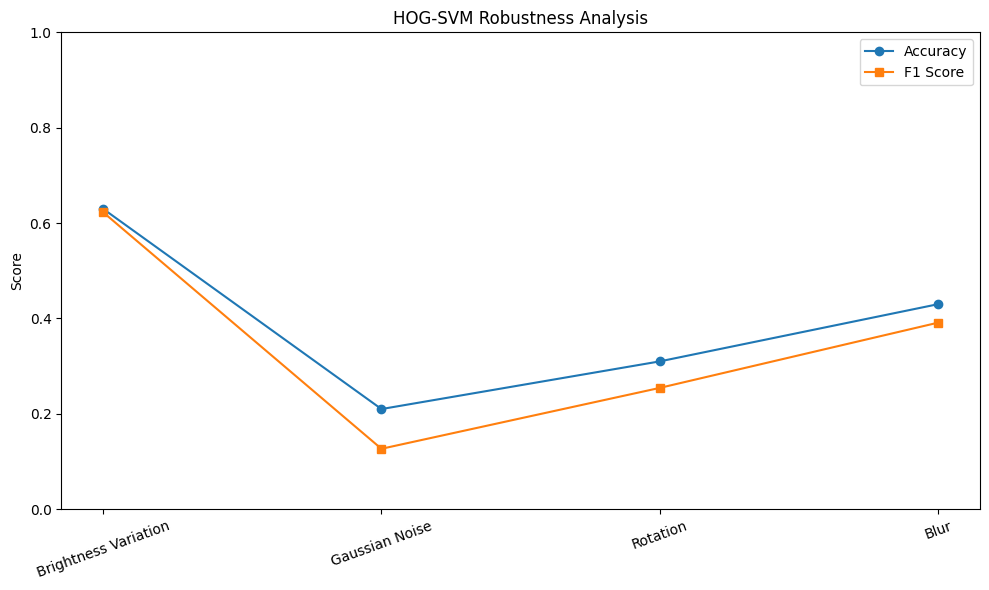

In [29]:
# ============================================================
# TASK 28 - ROBUSTNESS GRAPH
# ============================================================

plt.figure(figsize=(10, 6))

x = np.arange(
    len(robustness_df)
)

plt.plot(
    x,
    robustness_df["Accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    x,
    robustness_df["F1 Score"],
    marker="s",
    label="F1 Score"
)

plt.xticks(
    x,
    robustness_df["Condition"],
    rotation=20
)

plt.ylabel("Score")
plt.title("HOG-SVM Robustness Analysis")

plt.ylim(0, 1)

plt.legend()
plt.tight_layout()

plt.savefig(
    "/content/robustness_analysis.png",
    dpi=150
)

plt.show()

In [30]:
# ============================================================
# TASK 29 - INDUSTRIAL QUALITY CONTROL DECISION
# ============================================================

def industrial_qc_decision(
    image_path,
    model=svm_model
):

    # Load image
    image = cv2.imread(
        image_path,
        cv2.IMREAD_GRAYSCALE
    )

    if image is None:
        print("ERROR: Image could not be loaded.")
        return None

    # Resize
    image = cv2.resize(
        image,
        (128, 128)
    )

    # Normalize
    image = image.astype(
        np.float32
    ) / 255.0

    # HOG
    features = hog_from_image(
        image,
        best_orientations,
        best_cell_size
    )

    features = features.reshape(
        1, -1
    )

    # Prediction
    prediction = model.predict(
        features
    )[0]

    # Decision score
    decision_score = model.decision_function(
        features
    )

    # Relative confidence
    score_abs = np.abs(decision_score).flatten()

    confidence = (
        score_abs[0] /
        (np.max(score_abs) + 1e-8)
    ) * 100

    # Determine decision
    if prediction == 0:

        decision = "NON-DEFECTIVE"
        action = "ACCEPT PRODUCT"

    else:

        decision = "DEFECTIVE"
        action = "REJECT PRODUCT"

    print("\n" + "=" * 60)
    print("INDUSTRIAL QUALITY CONTROL RESULT")
    print("=" * 60)

    print("Prediction:", decision)
    print("Confidence: {:.2f}%".format(confidence))
    print("Action:", action)

    print("=" * 60)

    return {
        "prediction": decision,
        "confidence": confidence,
        "action": action
    }

In [31]:
# ============================================================
# TASK 30 - TEST INDUSTRIAL QC MODULE
# ============================================================

test_path = final_valid_df.iloc[0]["filepath"]

print("Testing image:")
print(test_path)

qc_result = industrial_qc_decision(
    test_path
)

Testing image:
/kaggle/input/neu-steel-surface-defect-detect-trainvalid-split/valid_images/rolled-in_scale_223.jpg

INDUSTRIAL QUALITY CONTROL RESULT
Prediction: DEFECTIVE
Confidence: 39.96%
Action: REJECT PRODUCT


In [32]:
# ============================================================
# TASK 31 - FINAL MARKDOWN REPORT
# ============================================================

from datetime import datetime

report_path = "/content/Lab_05_HOG_Industrial_Defect_Report.md"

best_accuracy = hog_results.iloc[0]["Accuracy"]
best_f1 = hog_results.iloc[0]["F1 Score"]

best_classifier = (
    "HOG + SVM"
    if svm_f1 >= rf_f1
    else "HOG + Random Forest"
)

report = f"""# Lab 05: HOG-Based Industrial Defect Detection and Classification

## 1. Introduction

This experiment applies Histogram of Oriented Gradients (HOG) features
for industrial surface defect detection and classification.

The system follows the pipeline:

Image → Preprocessing → HOG Feature Extraction →
Machine Learning Classifier → Defective/Non-Defective Decision

---

## 2. Industrial Application

The proposed system can be used in industrial quality control to
automatically inspect manufactured surfaces and identify defective
products.

---

## 3. Dataset Description

Dataset:
NEU Surface Defect Database (NEU-DET)

Training Images Used:
{len(final_train_images)}

Validation Images Used:
{len(final_valid_images)}

Classes:
{", ".join(map(str, class_names))}

---

## 4. Image Preprocessing

Images were:

1. Resized to 128 × 128 pixels.
2. Converted to grayscale.
3. Normalized to the range 0–1.

---

## 5. HOG Feature Extraction

HOG parameters were investigated using:

- Cell sizes: 4×4, 8×8, 16×16
- Orientations: 6, 9, 12
- Cells per block: 2×2
- Block normalization: L2-Hys

Best configuration:

Cell Size: {best_cell_size}×{best_cell_size}

Orientations: {best_orientations}

Tuning Accuracy: {best_accuracy:.4f}

Tuning F1 Score: {best_f1:.4f}

---

## 6. Classification Methodology

Two machine-learning classifiers were evaluated:

1. Linear SVM
2. Random Forest

---

## 7. Classifier Results

### HOG + SVM

Accuracy: {svm_accuracy:.4f}

F1 Score: {svm_f1:.4f}

### HOG + Random Forest

Accuracy: {rf_accuracy:.4f}

F1 Score: {rf_f1:.4f}

### Best Classifier

{best_classifier}

---

## 8. HOG Parameter Experiment

{hog_results.to_string(index=False)}

---

## 9. Robustness Analysis

{robustness_df.to_string(index=False)}

The robustness experiment investigated brightness variation,
Gaussian noise, rotation, and blur.

---

## 10. Industrial Deployment Discussion

The system can support automated industrial quality inspection.
A predicted defective product can be rejected while a non-defective
product can be accepted.

The final decision module produces:

- Prediction
- Confidence
- Recommended industrial action

---

## 11. Limitations

1. Performance depends on image quality.
2. Lighting changes can affect HOG features.
3. Noise and blur can reduce classification performance.
4. HOG primarily captures shape and edge information.
5. A larger and more diverse dataset may improve generalization.

---

## 12. Conclusion

HOG features were successfully applied to industrial surface images.
Different HOG cell sizes and orientation settings were compared.
SVM and Random Forest classifiers were trained and evaluated.

The system demonstrates how traditional computer vision and machine
learning can be combined for industrial quality control.

---

Report generated:
{datetime.now().strftime("%Y-%m-%d %H:%M:%S")}
"""

with open(
    report_path,
    "w",
    encoding="utf-8"
) as f:

    f.write(report)

print("Report created successfully:")
print(report_path)

print("\n" + "=" * 70)
print(report)

Report created successfully:
/content/Lab_05_HOG_Industrial_Defect_Report.md

# Lab 05: HOG-Based Industrial Defect Detection and Classification

## 1. Introduction

This experiment applies Histogram of Oriented Gradients (HOG) features
for industrial surface defect detection and classification.

The system follows the pipeline:

Image → Preprocessing → HOG Feature Extraction →
Machine Learning Classifier → Defective/Non-Defective Decision

---

## 2. Industrial Application

The proposed system can be used in industrial quality control to
automatically inspect manufactured surfaces and identify defective
products.

---

## 3. Dataset Description

Dataset:
NEU Surface Defect Database (NEU-DET)

Training Images Used:
1200

Validation Images Used:
100

Classes:
crazing, inclusion, patches, pitted_surface, rolled_in_scale, scratches

---

## 4. Image Preprocessing

Images were:

1. Resized to 128 × 128 pixels.
2. Converted to grayscale.
3. Normalized to the range 0–1.

---

## 5. HOG Featu

In [33]:
# ============================================================
# TASK 32 - DOWNLOAD REPORT
# ============================================================

from google.colab import files

files.download(
    "/content/Lab_05_HOG_Industrial_Defect_Report.md"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>